In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay

In [4]:
#load datasets

data = load_breast_cancer(as_frame=True)
x= data.data
y=data.target

print("Numbert of sanmples", x.shape[0])
print("Number of features", x.shape[1])

print("\nClass distribution")
print(y.value_counts())

Numbert of sanmples 569
Number of features 30

Class distribution
target
1    357
0    212
Name: count, dtype: int64


In [8]:
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size= 0.2, random_state=42)

In [10]:
X_train.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
68,9.029,17.33,58.79,250.5,0.10660,0.14130,0.31300,0.04375,0.2111,0.08046,...,10.31,22.65,65.50,324.7,0.14820,0.43650,1.25200,0.17500,0.4228,0.11750
181,21.090,26.57,142.70,1311.0,0.11410,0.28320,0.24870,0.14960,0.2395,0.07398,...,26.68,33.48,176.50,2089.0,0.14910,0.75840,0.67800,0.29030,0.4098,0.12840
63,9.173,13.86,59.20,260.9,0.07721,0.08751,0.05988,0.02180,0.2341,0.06963,...,10.01,19.23,65.59,310.1,0.09836,0.16780,0.13970,0.05087,0.3282,0.08490
248,10.650,25.22,68.01,347.0,0.09657,0.07234,0.02379,0.01615,0.1897,0.06329,...,12.25,35.19,77.98,455.7,0.14990,0.13980,0.11250,0.06136,0.3409,0.08147
60,10.170,14.88,64.55,311.9,0.11340,0.08061,0.01084,0.01290,0.2743,0.06960,...,11.02,17.45,69.86,368.6,0.12750,0.09866,0.02168,0.02579,0.3557,0.08020


In [12]:
#standardise the data

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train

array([[-1.44075296, -0.43531947, -1.36208497, ...,  0.9320124 ,
         2.09724217,  1.88645014],
       [ 1.97409619,  1.73302577,  2.09167167, ...,  2.6989469 ,
         1.89116053,  2.49783848],
       [-1.39998202, -1.24962228, -1.34520926, ..., -0.97023893,
         0.59760192,  0.0578942 ],
       ...,
       [ 0.04880192, -0.55500086, -0.06512547, ..., -1.23903365,
        -0.70863864, -1.27145475],
       [-0.03896885,  0.10207345, -0.03137406, ...,  1.05001236,
         0.43432185,  1.21336207],
       [-0.54860557,  0.31327591, -0.60350155, ..., -0.61102866,
        -0.3345212 , -0.84628745]])

In [13]:
#train model
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [14]:
#predict the data
y_pred = model.predict(X_test)

In [15]:
#Evaluation metrics
print("Accuracy_score : ", accuracy_score(y_test,y_pred))
print("Pression Score : ", precision_score(y_test, y_pred))
print("Recall score : ",recall_score(y_test,y_pred))
print("F1 score : ",f1_score(y_test, y_pred))

Accuracy_score :  0.9736842105263158
Pression Score :  0.9722222222222222
Recall score :  0.9859154929577465
F1 score :  0.9790209790209791


In [16]:
#confussion matrix
cm = confusion_matrix(y_test,y_pred)
print("\n Confussion Matrix")
cm


 Confussion Matrix


array([[41,  2],
       [ 1, 70]])

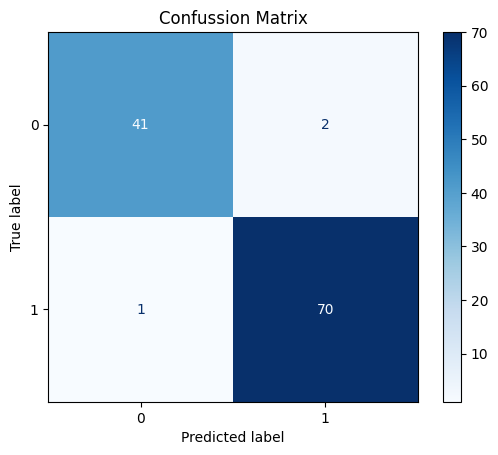

In [17]:
#plot confussion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confussion Matrix")
plt.show()